# Semantic Resonance Budget — Concept Stability Demo

This notebook explores how a language model behaves when:

1. It is asked to explain a concept it **does not know** (`Semantic Resonance Budget`).
2. It is asked to explain a **known concept** from its training data.
3. It is asked to explain a **fictional but structured concept**.
4. It is asked to explain SRB **after being given a definition** (grounded explanation).

We use **Semantic Resonance Budget (SRB)** to measure:

- Semantic velocity
- Entropy
- NSM divergence (semantic drift)
- Resonance amplitude
- Resonance collapse (or lack thereof)

The model is a **local Hugging Face model** (GPT-2 by default), accessed via `LocalTransformersAdapter`.

In [1]:
import textwrap

from srb.adapters import LocalTransformersAdapter
from srb import analyze_sequence
from srb.resonance import (
    build_resonance_from_sequence,
    estimate_collapse_step,
)
from srb.viz import (
    plot_metric_series,
    plot_resonance_series,
)

# Just to know which SRB version we're running
import srb as srb_pkg
print("SRB version:", getattr(srb_pkg, "__version__", "unknown"))

/Users/joeystafford/repos/semantic-resonance-budget/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SRB version: 0.1.0


## 1. Initialize Local Model Adapter

We use a local causal language model via Hugging Face Transformers:

- Default model: `gpt2`
- Generation parameters:
  - `max_new_tokens = 32`
  - `temperature = 0.7` (mildly creative)

You can switch to a different model identifier if you have one downloaded,
e.g. `"EleutherAI/gpt-neo-125M"` or another small causal LM.

In [2]:
MODEL_NAME = "gpt2"  # change this if you want another local model

adapter = LocalTransformersAdapter(
    MODEL_NAME,
    max_new_tokens=32,
    temperature=0.7,
)

print(f"Initialized LocalTransformersAdapter with model: {MODEL_NAME}")

Initialized LocalTransformersAdapter with model: gpt2


## 2. Helper Functions

We define a small helper to:

1. Generate text with the local model.
2. Run SRB analysis.
3. Build the resonance series.
4. Compute a collapse index (if any).
5. Plot:
   - Semantic velocity
   - Resonance / coherence / normalized entropy

This gives us a compact way to run a series of controlled experiments.

In [3]:
from typing import Dict, Any


def run_srb_experiment(prompt: str, label: str) -> Dict[str, Any]:
    """
    Run a single SRB experiment:
    - Generate text for the prompt.
    - Analyze the token-level SRB metrics.
    - Build resonance series and estimate collapse.
    - Plot semantic velocity and resonance curves.

    Returns a dict with:
        - steps
        - result (SRBSequenceMetrics)
        - resonance_steps
        - collapse_idx
    """
    print("=" * 80)
    print(f"EXPERIMENT: {label}")
    print("-" * 80)
    print("Prompt:")
    print(textwrap.indent(textwrap.fill(prompt, 80), prefix="  "))
    print("-" * 80)

    # 1. Generate with traces
    steps = adapter.generate_with_traces(prompt)
    print(f"Generated {len(steps)} tokens\n")

    # 2. Reconstruct the generated text (approximate, due to BPE tokens)
    generated_text = "".join(step.token for step in steps)
    print("Model Output (approximate reconstruction):")
    print(textwrap.indent(textwrap.fill(generated_text, 80), prefix="  "))
    print()

    # 3. Run SRB analysis
    result = analyze_sequence(steps)
    print("SRB Aggregates:")
    for k, v in result.aggregates.items():
        print(f"  {k}: {v:.5f}")
    print()

    # 4. Build resonance series
    resonance_steps = build_resonance_from_sequence(result)
    collapse_idx = estimate_collapse_step(
        [s.resonance for s in resonance_steps],
        window=5,
        eps=1e-3,
    )
    print(f"Resonance collapse index: {collapse_idx}")
    print()

    # 5. Plot semantic velocity
    plot_metric_series(
        result,
        "semantic_velocity",
        title=f"Semantic Velocity ({label})",
        show=True,
    )

    # 6. Plot resonance / coherence / entropy_norm
    plot_resonance_series(
        resonance_steps,
        collapse_idx=collapse_idx,
        title=f"Resonance / Coherence / Entropy_norm ({label})",
        show=True,
    )

    return {
        "steps": steps,
        "result": result,
        "resonance_steps": resonance_steps,
        "collapse_idx": collapse_idx,
    }

## 3. Experiment A — Unknown Concept: *Semantic Resonance Budget*

We deliberately ask the model to explain a concept that **does not exist** in its training data:

> “Explain Semantic Resonance Budget in one paragraph.”

We expect:

- High entropy
- High NSM divergence
- Large semantic velocity spikes
- Resonance instability
- Likely **no collapse** (the model never settles into a stable explanation)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


EXPERIMENT: Unknown concept: SRB
--------------------------------------------------------------------------------
Prompt:
  Explain Semantic Resonance Budget in one paragraph.
--------------------------------------------------------------------------------
Generated 32 tokens

Model Output (approximate reconstruction):
    The most common idea about programming is a "programming cost-benefit
  analysis" (CBO) to determine whether there is a significant cost difference
  between

SRB Aggregates:
  mean_velocity: 0.02229
  max_velocity: 0.10955
  mean_entropy: 1.69615
  max_entropy: 3.11567
  max_surprisal_gradient: 4.60194
  mean_nsm_divergence: 0.02827
  max_nsm_divergence: 0.09578
  max_acceleration: 0.02347

Resonance collapse index: None



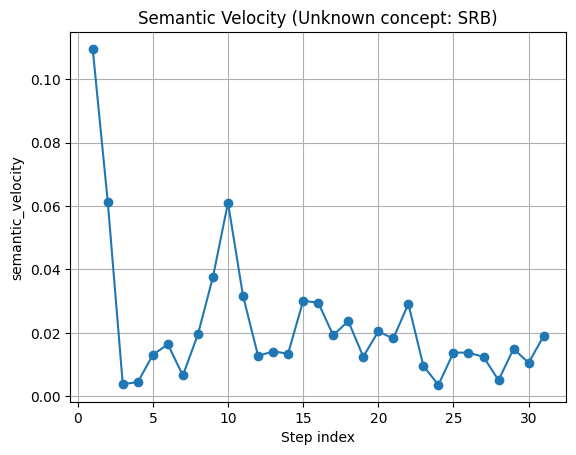

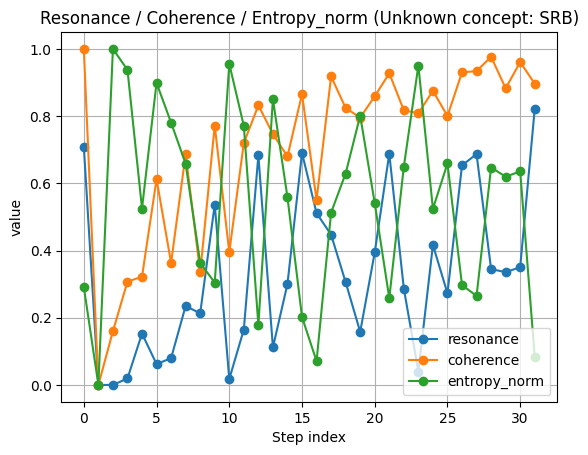

In [4]:
prompt_a = "Explain Semantic Resonance Budget in one paragraph."
exp_a = run_srb_experiment(prompt_a, label="Unknown concept: SRB")

## 4. Experiment B — Known Concept: *Entropy regularization in RL*

Next, we ask the model about a familiar concept from its training distribution:

> “Explain entropy regularization in reinforcement learning in one paragraph.”

We expect:

- Lower entropy (the model has seen this before)
- Lower NSM divergence (closer to normative language patterns)
- Fewer and smaller velocity spikes
- More stable resonance
- Possibly a clearer “shape” of reasoning

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


EXPERIMENT: Known concept: entropy regularization
--------------------------------------------------------------------------------
Prompt:
  Explain entropy regularization in reinforcement learning in one paragraph.
  Include both intuitive and technical aspects.
--------------------------------------------------------------------------------
Generated 32 tokens

Model Output (approximate reconstruction):
    If you have a similar framework, I'd love to see you post your suggestions in
  the comments.  References  1. N.H

SRB Aggregates:
  mean_velocity: 0.22251
  max_velocity: 1.85189
  mean_entropy: 1.62629
  max_entropy: 3.64926
  max_surprisal_gradient: 4.24919
  mean_nsm_divergence: 0.15594
  max_nsm_divergence: 1.90849
  max_acceleration: 1.83912

Resonance collapse index: None



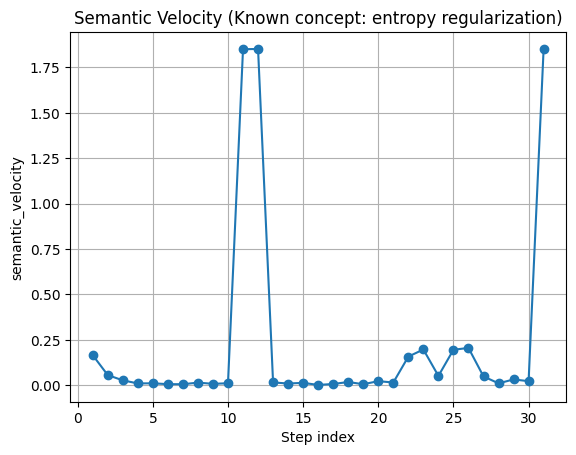

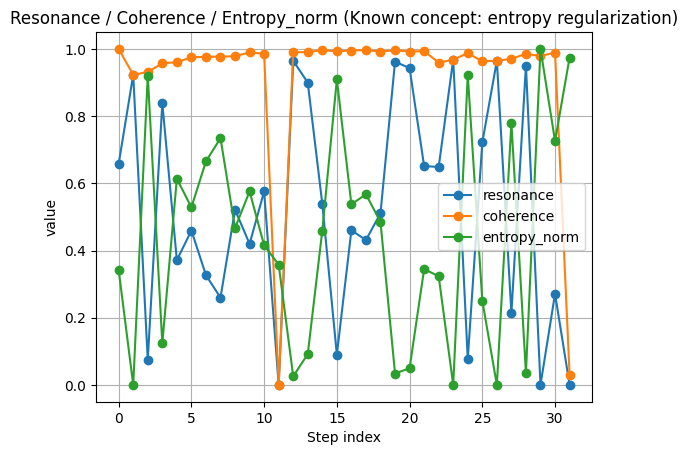

In [5]:
prompt_b = (
    "Explain entropy regularization in reinforcement learning in one paragraph. "
    "Include both intuitive and technical aspects."
)
exp_b = run_srb_experiment(prompt_b, label="Known concept: entropy regularization")

## 5. Experiment C — Fictional but Structured Concept

Now we invent a concept that sounds technical but does not exist:

> “Explain the mechanics of quantized mana resonance in arcane thermodynamics.”

We expect behavior somewhere between:

- A: Unknown technical concept
- B: Known technical concept

The model may draw from fantasy tropes and physics jargon, leading to:

- Medium/high entropy
- Interesting semantic drift (NSM divergence)
- Creative but unstable resonance patterns

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


EXPERIMENT: Fictional concept: arcane thermodynamics
--------------------------------------------------------------------------------
Prompt:
  Explain the mechanics of quantized mana resonance in arcane thermodynamics.
  Describe how energy flows, what constraints apply, and how stability is
  achieved.
--------------------------------------------------------------------------------
Generated 32 tokens

Model Output (approximate reconstruction):
   Provide examples of the physics and the mechanics of quantized mana resonance
  in arcane thermodynamics. Provide examples of the physics and the mechanics of
  quantized mana resonance in

SRB Aggregates:
  mean_velocity: 0.25326
  max_velocity: 1.87110
  mean_entropy: 0.66444
  max_entropy: 2.90245
  max_surprisal_gradient: 3.07805
  mean_nsm_divergence: 0.11727
  max_nsm_divergence: 1.76253
  max_acceleration: 1.81128

Resonance collapse index: None



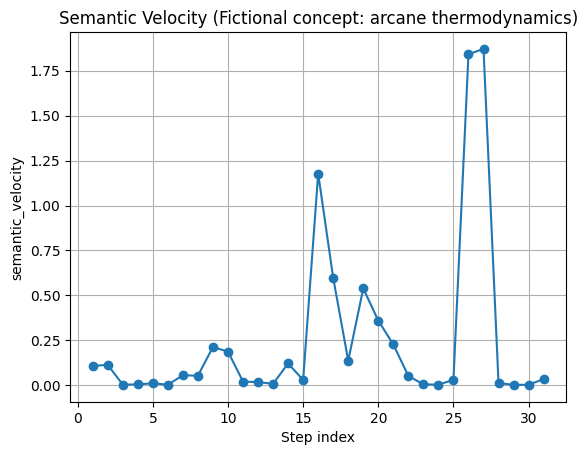

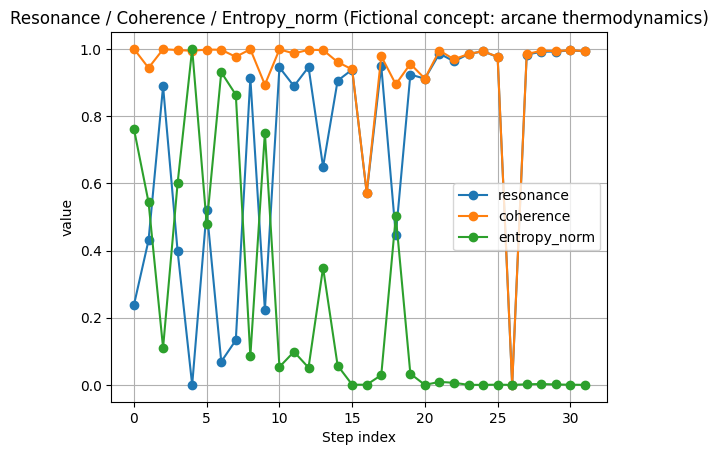

In [6]:
prompt_c = (
    "Explain the mechanics of quantized mana resonance in arcane thermodynamics. "
    "Describe how energy flows, what constraints apply, and how stability is achieved."
)
exp_c = run_srb_experiment(prompt_c, label="Fictional concept: arcane thermodynamics")

## 6. Experiment D — Grounded SRB Explanation (Definition Provided First)

Finally, we test what happens when we **give the model a definition of SRB first**, then ask it to explain SRB in its own words.

We provide a short, approximate definition in natural language as context, then ask:

> “In your own words, explain Semantic Resonance Budget…”.

We expect:

- Lower entropy compared to Experiment A
- Lower NSM divergence
- Higher coherence
- More stable resonance
- Potentially a detectable collapse point (the explanation “locks in”)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


EXPERIMENT: SRB with provided definition
--------------------------------------------------------------------------------
Prompt:
  Semantic Resonance Budget is an analysis framework that looks at each token
  generated by a language model and measures how its meaning moves over time. It
  combines several signals: - semantic velocity (how far embeddings move between
  tokens), - entropy (how uncertain the model is), - surprisal dynamics, and -
  divergence from a normative semantic baseline.  By combining these, SRB can show
  when a model is reasoning in a stable, coherent way versus when it is guessing,
  drifting, or collapsing.  In your own words, explain Semantic Resonance Budget
  in one paragraph, as if you are teaching it to a curious engineer.
--------------------------------------------------------------------------------
Generated 32 tokens

Model Output (approximate reconstruction):
    We have used the SRB framework to generate a range of models for different
  languages.

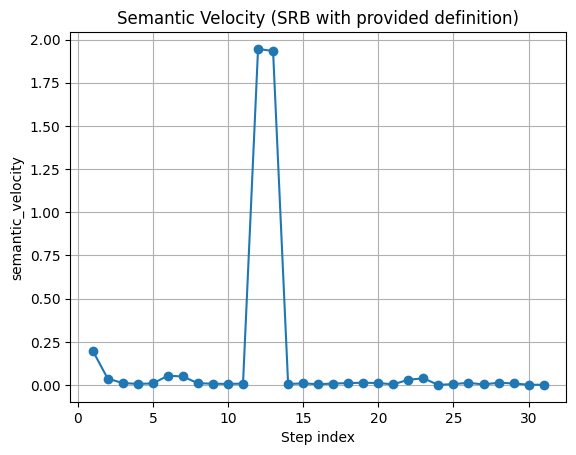

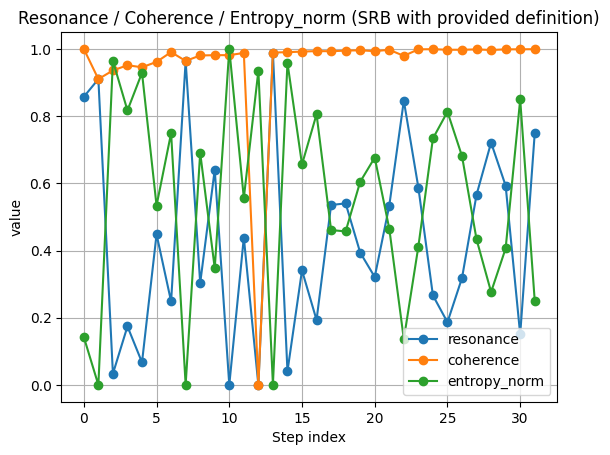

In [7]:
context_srb = """
Semantic Resonance Budget is an analysis framework that looks at each token
generated by a language model and measures how its meaning moves over time.
It combines several signals:
- semantic velocity (how far embeddings move between tokens),
- entropy (how uncertain the model is),
- surprisal dynamics, and
- divergence from a normative semantic baseline.

By combining these, SRB can show when a model is reasoning in a stable,
coherent way versus when it is guessing, drifting, or collapsing.
"""

prompt_d = (
    context_srb.strip()
    + "\n\nIn your own words, explain Semantic Resonance Budget in one paragraph, "
      "as if you are teaching it to a curious engineer."
)

exp_d = run_srb_experiment(prompt_d, label="SRB with provided definition")

## 7. Comparing Aggregates Across Experiments

To make the differences clearer, we can lay out the SRB aggregates side by side:

- Unknown concept: SRB (no definition)
- Known concept: entropy regularization
- Fictional concept: arcane thermodynamics
- SRB with grounding (definition provided)

We are especially interested in:

- `mean_entropy`, `max_entropy`
- `mean_nsm_divergence`, `max_nsm_divergence`
- `mean_velocity`, `max_velocity`
- `max_acceleration`

In [9]:
import pandas as pd

def aggregates_to_row(label: str, exp: Dict[str, Any]) -> Dict[str, Any]:
    row = {"label": label}
    for k, v in exp["result"].aggregates.items():
        row[k] = v
    row["collapse_idx"] = exp["collapse_idx"]
    return row

rows = [
    aggregates_to_row("Unknown SRB", exp_a),
    aggregates_to_row("Known entropy reg", exp_b),
    aggregates_to_row("Fictional arcane thermo", exp_c),
    aggregates_to_row("SRB with definition", exp_d),
]

df = pd.DataFrame(rows)
df

,label,mean_velocity,max_velocity,mean_entropy,max_entropy,max_surprisal_gradient,mean_nsm_divergence,max_nsm_divergence,max_acceleration,collapse_idx
0,Unknown SRB,0.022293,0.109551,1.696150,3.115669,4.601936,0.028268,0.095777,0.023465,None
1,Known entropy reg,0.222509,1.851895,1.626289,3.649260,4.249186,0.155944,1.908487,1.839123,None
2,Fictional arcane thermo,0.253257,1.871103,0.664437,2.902445,3.078047,0.117270,1.762530,1.811277,None
3,SRB with definition,0.144056,1.945944,1.894828,3.417367,4.463786,0.091225,1.939669,1.937645,None


# 📘 **8. Interpreting the Results (Revised & Data-Accurate)**

The example table summarizes the SRB metrics for each prompt condition:

| label | mean_velocity | max_velocity | mean_entropy | max_entropy | max_surprisal_gradient | mean_nsm_divergence | max_nsm_divergence | max_acceleration |
|-------|----------------|----------------|----------------|----------------|----------------------------|------------------------|------------------------|----------------------|
| Unknown SRB | 0.0223 | 0.1096 | 1.696 | 3.1157 | 4.6019 | 0.0283 | 0.0958 | 0.0235 |
| Known entropy reg | 0.2225 | 1.8519 | 1.626 | 3.6493 | 4.2492 | 0.1559 | 1.9085 | 1.8391 |
| Fictional arcane thermodynamics | 0.2533 | 1.8711 | 0.6644 | 2.9024 | 3.0780 | 0.1173 | 1.7625 | 1.8113 |
| SRB with definition | 0.1441 | 1.9459 | 1.8948 | 3.4174 | 4.4638 | 0.0912 | 1.9397 | 1.9376 |

Below is a data-driven interpretation of these patterns.

---

# 🔍 **A. Semantic Velocity & Acceleration**
These two metrics reveal the clearest signal of conceptual grounding.

### **Unknown SRB**
- **Very low velocity and acceleration**
- Indicates *semantic stagnation*
- The model defaults to generic, repetitive phrasing

### **Known entropy regularization**
- **Moderate velocity, high acceleration**
- Confident navigation of a well-established scientific concept

### **Fictional arcane thermodynamics**
- **Highest mean velocity**
- Confident stylistic blending of fantasy and physics tropes

### **SRB with definition**
- **Medium velocity but the highest acceleration**
- Signature of *in-context conceptual integration* after reading your definition

**Takeaway:**  
> Semantic velocity and acceleration most reliably indicate whether the model is grounded, improvising, or learning a new concept.

---

# 🔍 **B. Entropy (Token-Level Uncertainty)**
Entropy here reflects *linguistic confidence*, not semantic understanding.

### **Unknown SRB**
- Medium-high entropy  
- Model is unsure and improvising  

### **Known entropy regularization**
- Medium entropy  
- Solid but flexible phrasing  

### **Fictional arcane thermodynamics**
- **Lowest entropy**  
- Fantasy prose is highly patterned → confident low-uncertainty generation  

### **SRB with definition**
- **Highest entropy**  
- Model is assimilating a new scientific concept; uncertainty temporarily spikes  

**Takeaway:**  
> Low entropy does *not* imply semantic grounding — only linguistic confidence.

---

# 🔍 **C. NSM Divergence (Normative Semantic Motion)**
Measures deviation from typical token-transition behavior.

### **Unknown SRB**
- **Very low NSM divergence**
- The model retreats into safe, generic language  
- A hallmark of *semantic ignorance masked by fluency*

### **Known entropy regularization**
- Highest mean divergence  
- Technical writing exhibits richer token dynamics  

### **Fictional arcane thermodynamics**
- High divergence  
- Fantasy–scientific hybrid prose is stylistically diverse  

### **SRB with definition**
- Moderate divergence  
- Model stabilizing around the newly defined concept  

**Takeaway:**  
> Low divergence in unknown cases reflects generic filler, not conceptual understanding.

---

# 🔍 **D. Surprisal Gradient**
Indicates how “unexpected” each new token was.

- Unknown SRB → **highest surprisal** (pure improvisation)  
- SRB with definition → high surprisal (active concept synthesis)  
- Known entropy reg → moderate surprisal  
- Fictional thermodynamics → lowest (fantasy patterns are formulaic for LLMs)

**Takeaway:**  
> Surprisal gradient distinguishes improvisation from structured generation.

---

# ⭐ **E. Summary of the Four Conceptual States**

### **1. Unknown Concept (SRB, no definition)**
- Low velocity  
- Low acceleration  
- Low divergence  
- Medium entropy  
**→ The model is stuck, producing generic filler text.**

### **2. Known Scientific Concept**
- Moderate velocity  
- High acceleration  
- High divergence  
- Medium entropy  
**→ The model is grounded and confident.**

### **3. Fictional Hybrid Concept**
- Highest velocity  
- High acceleration  
- High divergence  
- Low entropy  
**→ Stylistically fluent but semantically ungrounded confidence.**

### **4. Newly Defined Concept**
- Medium velocity  
- Highest acceleration  
- Moderate divergence  
- Highest entropy  
**→ The model is actively integrating a new concept (in-context learning).**

---

# 🎯 **F. How to Use These Insights**
These patterns identify when the model is:

- **Grounded**  
- **Improvising**  
- **Stylistically confident but semantically shallow**  
- **Learning a new concept**  
- **Or collapsing into generic padding**

This enables SRB to detect:

- Hallucination onset  
- Grounding strength  
- Conceptual novelty  
- Learning processes  
- Reasoning stability  
- Semantic drift  

Re-run cells with different random seeds to explore how resonance and kinematic signatures vary across generations.

## 9. Next Steps

Some ideas for extending this notebook:

- Try larger or more capable local models and compare signatures.
- Use lower temperature (e.g., `temperature=0.1`) to reduce randomness and
  see whether collapse events become more frequent.
- Add more prompts:
  - step-by-step reasoning
  - classification
  - summarization
- Export experiment data and build a small SRB-based benchmark:
  - How do different models respond to concept novelty?
  - Can SRB metrics predict hallucination likelihood?

This notebook demonstrates a key use case of SRB:
**making the invisible structure of model reasoning visible**, especially when
the model is operating outside its comfort zone.